In [4]:
from dataclasses import replace
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset
from src.predict import AnchorSlice, load_predict_config, load_predictor
from src.train import load_train_config


def pick_anchor(ds, axis):
    idx = ds.condition_indices[axis]
    pos = int(torch.randint(len(idx), ()).item())
    return ds[idx[pos]][0][0].numpy().astype("uint8")

In [5]:
PREDICT_CONFIG = ROOT / "config" / "predict.yaml"
ANCHOR_AXIS = 0
AXES = ("axis 0", "axis 1", "axis 2")
OFFSETS = (-2, -1, 0, 1, 2)

In [6]:
cfg = load_predict_config(PREDICT_CONFIG)
run = ROOT / cfg.run_dir
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pred = load_predictor(run, device=dev)
opts = cfg.make_options(pred)

train = load_train_config(run / "model.yaml")
data = replace(train.data, augment=False)
ds = build_dataset(data)
img = pick_anchor(ds, ANCHOR_AXIS)
anc = AnchorSlice(
    img,
    axis=ANCHOR_AXIS,
    index=opts.volume_size // 2,
)

In [7]:
start = time.perf_counter()
vol, stats = pred.predict(opts, anchors=[anc])
secs = time.perf_counter() - start
fracs = [round(v, 4) for v in stats["phase_fractions"]]
print(
    f"volume={tuple(vol.shape)} anchor={anc.index} "
    f"elapsed={secs:.1f}s fractions={fracs}"
)

Image MPDD: 100%|██████████| 100/100 [02:37<00:00,  1.57s/it]

volume=(64, 64, 64) anchor=32 elapsed=157.6s fractions=[0.5188, 0.0765, 0.4047]


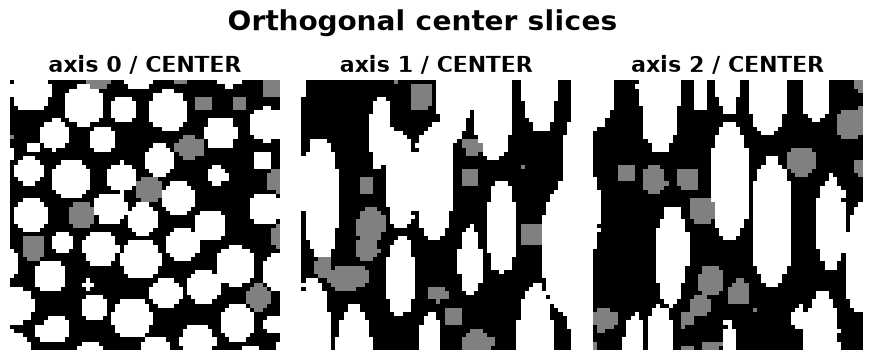

In [8]:
center = opts.volume_size // 2
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for dim, ax in enumerate(axes):
    ax.imshow(
        vol.select(dim, center),
        cmap="gray",
        vmin=0,
        vmax=opts.num_phases - 1,
        interpolation="nearest",
    )
    ax.set_title(f"{AXES[dim]} / CENTER", fontsize=16, fontweight="bold")
    ax.axis("off")
fig.suptitle("Orthogonal center slices", fontsize=20, fontweight="bold")
fig.subplots_adjust(top=0.82, wspace=0.08)
plt.show()

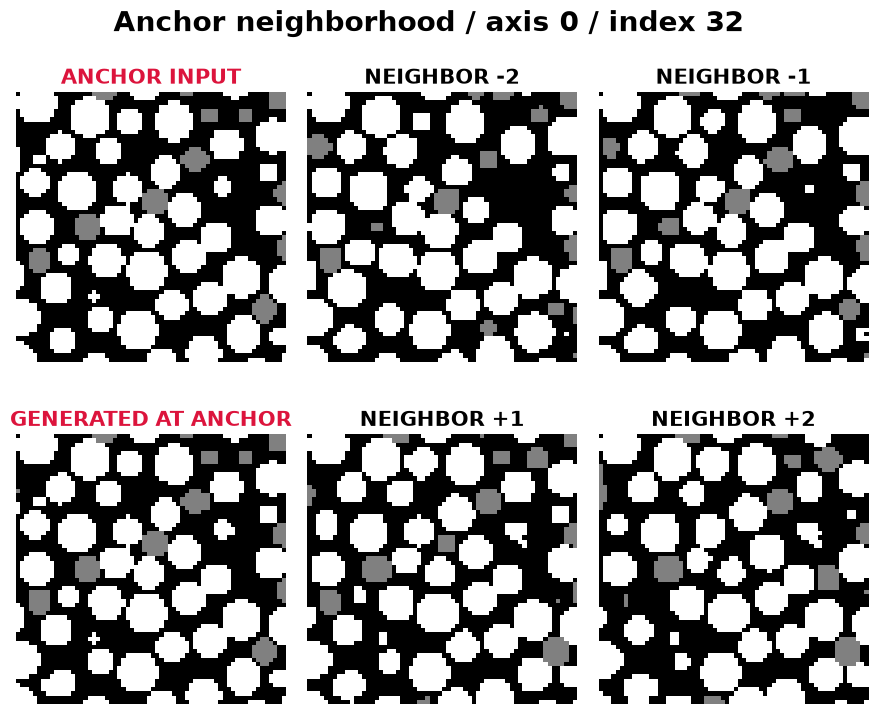

In [9]:
near = [
    vol.select(anc.axis, anc.index + offset).numpy()
    for offset in OFFSETS
]
panels = [(anc.image, "ANCHOR INPUT", True)] + [
    (
        image,
        "GENERATED AT ANCHOR" if offset == 0 else f"NEIGHBOR {offset:+d}",
        offset == 0,
    )
    for offset, image in zip(OFFSETS, near)
]

fig, axes = plt.subplots(2, 3, figsize=(11, 8))
for ax, (img, title, marked) in zip(axes.ravel(), panels):
    ax.imshow(
        img,
        cmap="gray",
        vmin=0,
        vmax=opts.num_phases - 1,
        interpolation="nearest",
    )
    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        color="crimson" if marked else "black",
    )
    ax.axis("off")
fig.suptitle(
    f"Anchor neighborhood / {AXES[anc.axis]} / index {anc.index}",
    fontsize=20,
    fontweight="bold",
)
fig.subplots_adjust(top=0.88, hspace=0.25, wspace=0.08)
plt.show()

In [11]:
%gui qt
import napari

viewer = napari.Viewer(ndisplay=3)
viewer.add_labels(vol.numpy(), name="MPDD volume")
viewer

Viewer(mouse_move_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x000001DD8454FD80>, <function layers_scroll at 0x000001DD8454FE20>], mouse_drag_callbacks=[<function drag_to_zoom at 0x000001DD8454FF60>], mouse_double_click_callbacks=[<function double_click_to_zoom at 0x000001DD8454FEC0>], camera=Camera(center=(31.5, 31.5, 31.5), zoom=8.38671875, angles=(0.0, 0.0, 0.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>), synced=True), cursor=Cursor(position=(1.0, 1.0, 0.0), viewbox=None, scaled=True, size=1.0, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=3, order=(0, 1, 2), axis_labels=('-3', '-2', '-1'), rollable=(True, True, True), range=(RangeTuple(start=0.0, stop=63.0, step=1.0), RangeTuple(start=0.0, stop=63.0, step=1.0), RangeTuple(start=0.0, stop=63.0, step=1.0)), margin_left=(0.0, 0.0, 0.0), margin_rig